
XRD_data\A_17-09-26
Peak   2θ (°)       ± uncertainty     Intensity       d (Å)      ± uncertainty
-------------------------------------------------------------------------------------
   1    41.7138   ±  0.0018          739    2.16355   ± 0.00009
   2    48.5482   ±  0.0027          365    1.87374   ± 0.00010
   3    71.0812   ±  0.0048          176    1.32518   ± 0.00008
   4    85.9070   ±  0.0051          184    1.13046   ± 0.00005
   5    90.7545   ±  0.0140           46    1.08227   ± 0.00013

Goodness of fit:
χ² = 3979.06
Degrees of freedom = 1984
Reduced χ² = 2.006

XRD_data\A_17-09-26_2
Peak   2θ (°)       ± uncertainty     Intensity       d (Å)      ± uncertainty
-------------------------------------------------------------------------------------
   1    41.7160   ±  0.0017          761    2.16344   ± 0.00009
   2    48.5479   ±  0.0027          381    1.87375   ± 0.00010
   3    71.0743   ±  0.0045          187    1.32529   ± 0.00007
   4    85.9244   ±  0.0050          1

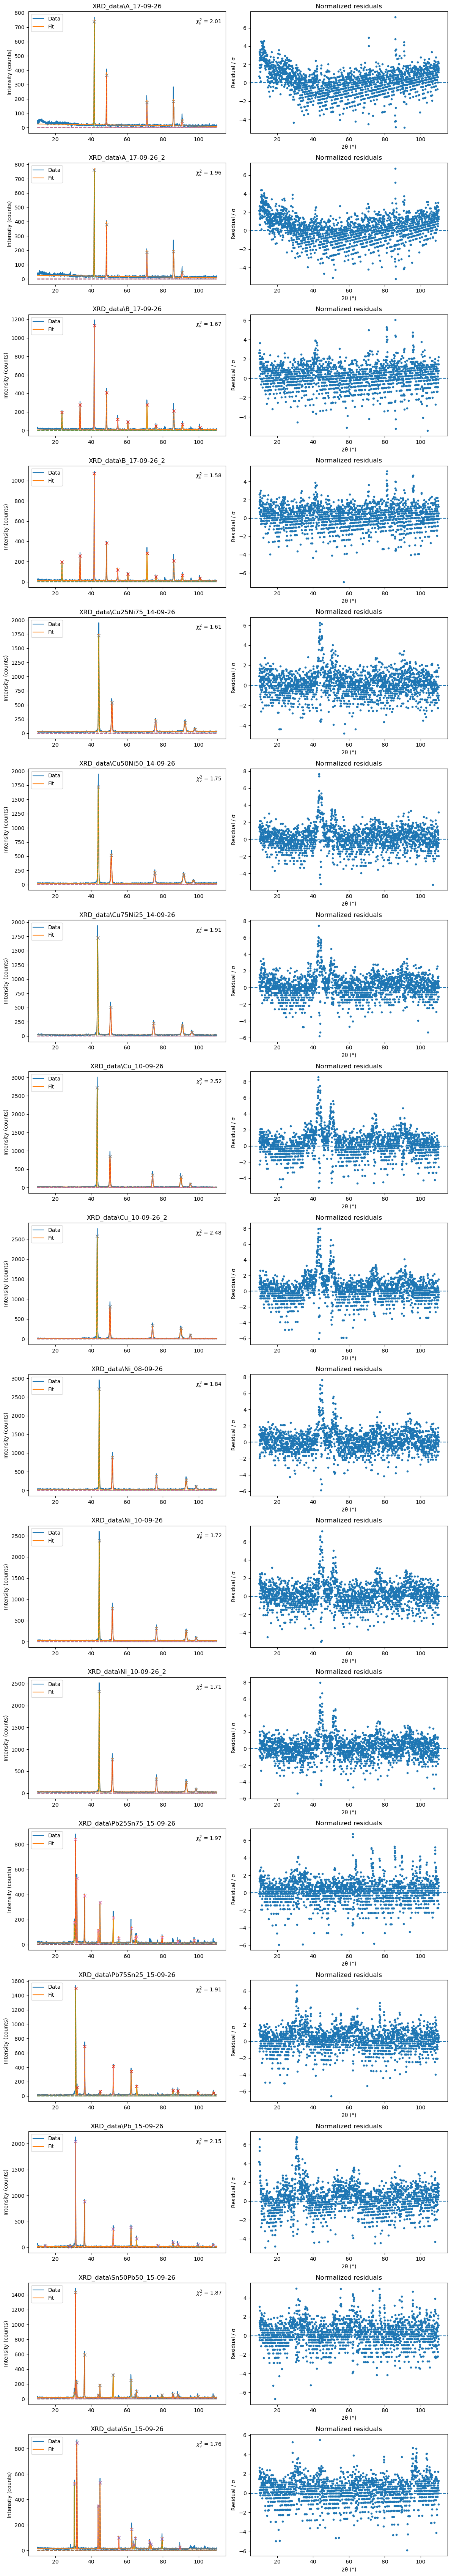

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from glob import glob

files = sorted(glob("XRD_data/*.UXD"))

fig, axes = plt.subplots(
    len(files), 2,
    figsize=(12, 4 * len(files))
)

if len(files) == 1:
    axes = np.array([axes])

data_axes = axes[:, 0]
residual_axes = axes[:, 1]

peak_angles = {}
peak_intensities = {}
peak_d = {}
peak_angle_errors = {}
peak_d_errors = {}


# ---------------------------------------------------------
# Gaussian functions
# ---------------------------------------------------------

def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))


def gaussian_sum(x, *params):

    # First two parameters are the linear background
    m = params[0]
    b = params[1]

    y = m * x + b

    # Remaining parameters are the Gaussian peaks
    for i in range(2, len(params), 3):

        A = params[i]
        mu = params[i + 1]
        sigma = params[i + 2]

        y += gaussian(x, A, mu, sigma)

    return y


# ---------------------------------------------------------
# Bragg's law
# ---------------------------------------------------------

wavelength = 1.5406  # Angstrom, Cu K_alpha
n = 1


for i, file in enumerate(files):

    # -----------------------------------------------------
    # Load data
    # -----------------------------------------------------

    data = np.loadtxt(file)

    twotheta = data[:, 0]
    intensity = data[:, 1]

    # Uncertainty from counting statistics
    intensity_error = np.sqrt(np.maximum(intensity, 1))


    # -----------------------------------------------------
    # Step 1: Find rough peak positions
    # -----------------------------------------------------

    peaks, _ = find_peaks(
        intensity,
        prominence=50
    )

    rough_positions = twotheta[peaks]
    rough_heights = intensity[peaks]


    # -----------------------------------------------------
    # Step 2: Initial guesses
    # -----------------------------------------------------

    initial_guess = [
        0,                  # background slope
        np.min(intensity)   # background intercept
    ]

    for position, height in zip(rough_positions, rough_heights):

        initial_guess.extend([
            height,      # amplitude
            position,    # center
            0.15         # sigma
        ])


    # -----------------------------------------------------
    # Step 3: Bounds
    # -----------------------------------------------------

    lower_bounds = [
        -np.inf,    # background slope
        0           # background intercept
    ]

    upper_bounds = [
        np.inf,
        np.inf
    ]

    for position in rough_positions:

        lower_bounds.extend([
            0,
            position - 1.0,
            0.01
        ])

        upper_bounds.extend([
            np.inf,
            position + 1.0,
            1.0
        ])


    # -----------------------------------------------------
    # Step 4: Fit
    # -----------------------------------------------------

    try:

        popt, pcov = curve_fit(
            gaussian_sum,
            twotheta,
            intensity,
            p0=initial_guess,
            sigma=intensity_error,
            absolute_sigma=True,
            bounds=(lower_bounds, upper_bounds),
            maxfev=50000
        )

        # Parameter uncertainties
        perr = np.sqrt(np.diag(pcov))

        fit_success = True

    except (RuntimeError, ValueError):

        print("Fit failed for:", file)

        fit_success = False


    # -----------------------------------------------------
    # Store fitted peak information
    # -----------------------------------------------------

    name = file.split("/")[-1].replace(".UXD", "")

    if fit_success:

        fitted_angles = []
        fitted_intensities = []
        fitted_d = []
        fitted_angle_errors = []
        fitted_d_errors = []


        # -------------------------------------------------
        # Calculate fit
        # -------------------------------------------------

        fit = gaussian_sum(
            twotheta,
            *popt
        )


        # -------------------------------------------------
        # Calculate residuals
        # -------------------------------------------------

        residuals = intensity - fit

        normalized_residuals = (
            residuals / intensity_error
        )


        # -------------------------------------------------
        # Chi squared
        # -------------------------------------------------

        chi_squared = np.sum(
            (residuals / intensity_error)**2
        )

        N = len(intensity)

        # 2 background parameters + 3 per peak
        n_parameters = len(popt)

        degrees_of_freedom = (
            N - n_parameters
        )

        reduced_chi_squared = (
            chi_squared / degrees_of_freedom
        )


        # -------------------------------------------------
        # Store peak parameters
        # -------------------------------------------------

        for j in range(len(rough_positions)):

            # +2 because the first two parameters
            # are the background slope and intercept
            A = popt[2 + 3*j]
            mu = popt[2 + 3*j + 1]
            sigma = popt[2 + 3*j + 2]

            mu_error = perr[2 + 3*j + 1]


            # ---------------------------------------------
            # Bragg's law
            # ---------------------------------------------

            theta = np.radians(mu / 2)

            d = wavelength / (
                2 * np.sin(theta)
            )

            d_error = (
                wavelength
                / (2 * np.sin(theta)**2)
                * np.cos(theta)
                * (np.radians(mu_error) / 2)
            )


            fitted_angles.append(mu)
            fitted_intensities.append(A)
            fitted_d.append(d)
            fitted_angle_errors.append(mu_error)
            fitted_d_errors.append(d_error)


        peak_angles[name] = np.array(fitted_angles)
        peak_intensities[name] = np.array(fitted_intensities)
        peak_d[name] = np.array(fitted_d)
        peak_angle_errors[name] = np.array(fitted_angle_errors)
        peak_d_errors[name] = np.array(fitted_d_errors)


        # -------------------------------------------------
        # Print results
        # -------------------------------------------------

        print("\n" + "=" * 85)
        print(name)
        print("=" * 85)

        print(
            "Peak   2θ (°)       ± uncertainty     "
            "Intensity       d (Å)      ± uncertainty"
        )

        print("-" * 85)

        for j in range(len(fitted_angles)):

            print(
                f"{j+1:4d}   "
                f"{fitted_angles[j]:8.4f}   "
                f"± {fitted_angle_errors[j]:7.4f}   "
                f"{fitted_intensities[j]:10.0f}   "
                f"{fitted_d[j]:8.5f}"
                f"   ± {fitted_d_errors[j]:7.5f}"
            )


        # -------------------------------------------------
        # Print goodness of fit
        # -------------------------------------------------

        print("\nGoodness of fit:")
        print(f"χ² = {chi_squared:.2f}")
        print(f"Degrees of freedom = {degrees_of_freedom}")
        print(f"Reduced χ² = {reduced_chi_squared:.3f}")


        # -------------------------------------------------
        # Plot original data
        # -------------------------------------------------

        data_axes[i].plot(
            twotheta,
            intensity,
            label="Data"
        )


        # -------------------------------------------------
        # Plot total Gaussian + background fit
        # -------------------------------------------------

        data_axes[i].plot(
            twotheta,
            fit,
            label="Fit"
        )


        # -------------------------------------------------
        # Plot individual Gaussians
        # -------------------------------------------------

        for j in range(len(rough_positions)):

            A = popt[2 + 3*j]
            mu = popt[2 + 3*j + 1]
            sigma = popt[2 + 3*j + 2]

            component = gaussian(
                twotheta,
                A,
                mu,
                sigma
            )

            data_axes[i].plot(
                twotheta,
                component,
                "--",
                alpha=0.5
            )


        # -------------------------------------------------
        # Plot fitted centers
        # -------------------------------------------------

        data_axes[i].plot(
            fitted_angles,
            fitted_intensities,
            "x"
        )


        data_axes[i].set_ylabel(
            "Intensity (counts)"
        )

        data_axes[i].set_title(name)

        data_axes[i].text(
            0.98, 0.95,
            f"$\\chi^2_\\nu$ = {reduced_chi_squared:.2f}",
            transform=data_axes[i].transAxes,
            ha="right",
            va="top"
        )

        data_axes[i].legend()


        # -------------------------------------------------
        # Plot residuals
        # -------------------------------------------------

        residual_axes[i].plot(
            twotheta,
            normalized_residuals,
            "."
        )

        residual_axes[i].axhline(
            0,
            linestyle="--"
        )

        residual_axes[i].set_xlabel(
            "2θ (°)"
        )

        residual_axes[i].set_ylabel(
            "Residual / σ"
        )

        residual_axes[i].set_title(
            "Normalized residuals"
        )


    else:

        data_axes[i].plot(
            twotheta,
            intensity
        )

        data_axes[i].set_ylabel(
            "Intensity (counts)"
        )

        data_axes[i].set_title(name)


# ---------------------------------------------------------
# Layout
# ---------------------------------------------------------

plt.tight_layout()
plt.show()


XRD_data\A_17-09-26
cubic        P: χ²ᵣ = 1.153e+07
cubic        I: χ²ᵣ = 1.097e+07
cubic        F: χ²ᵣ = 1.412e+07
tetragonal   P: χ²ᵣ = 1.502e+07
tetragonal   I: χ²ᵣ = 1.227e+07
orthorhombic P: χ²ᵣ = 2.254e+07
orthorhombic I: χ²ᵣ = 1.854e+07
orthorhombic F: χ²ᵣ = 3.901e+06
orthorhombic C: χ²ᵣ = 3.505e+06

XRD_data\A_17-09-26_2
cubic        P: χ²ᵣ = 1.238e+07
cubic        I: χ²ᵣ = 1.176e+07
cubic        F: χ²ᵣ = 1.499e+07
tetragonal   P: χ²ᵣ = 1.613e+07
tetragonal   I: χ²ᵣ = 1.304e+07
orthorhombic P: χ²ᵣ = 2.42e+07
orthorhombic I: χ²ᵣ = 1.982e+07
orthorhombic F: χ²ᵣ = 4.098e+06
orthorhombic C: χ²ᵣ = 3.697e+06

XRD_data\B_17-09-26
cubic        P: χ²ᵣ = 3.744e+06
cubic        I: χ²ᵣ = 5.033e+06
cubic        F: χ²ᵣ = 4.752e+06
tetragonal   P: χ²ᵣ = 1.973e+06
tetragonal   I: χ²ᵣ = 3.688e+06
orthorhombic P: χ²ᵣ = 1.672e+06
orthorhombic I: χ²ᵣ = 3.329e+06
orthorhombic F: χ²ᵣ = 3.422e+06
orthorhombic C: χ²ᵣ = 4.26e+06

XRD_data\B_17-09-26_2
cubic        P: χ²ᵣ = 3.797e+06
cubic        I: χ²

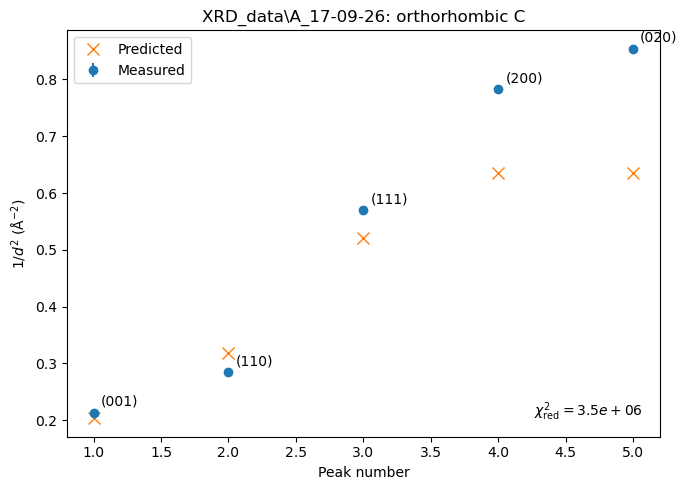

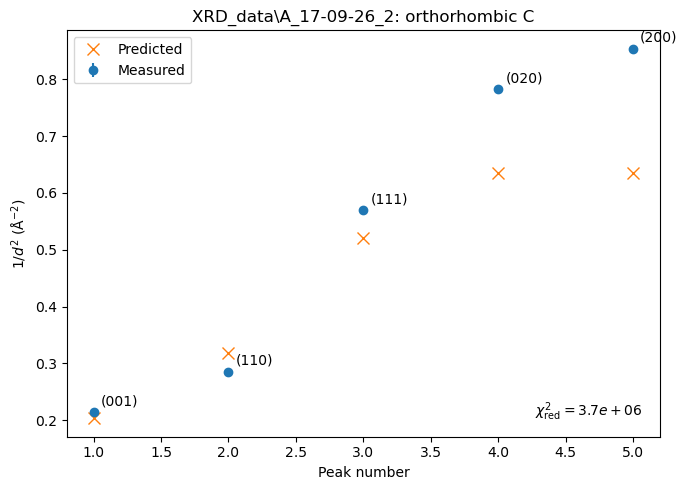

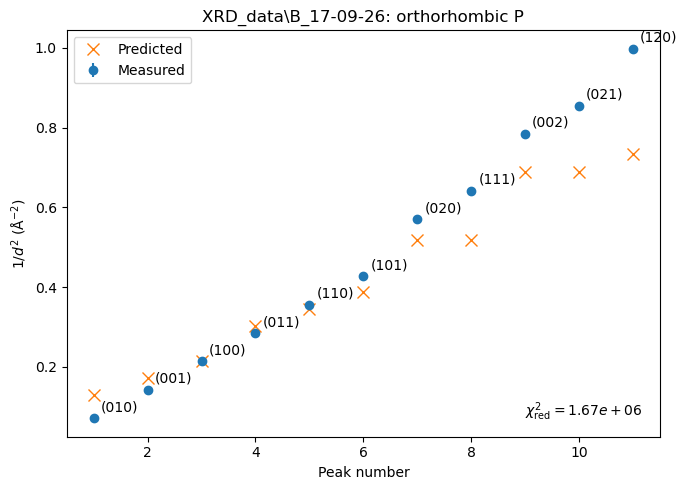

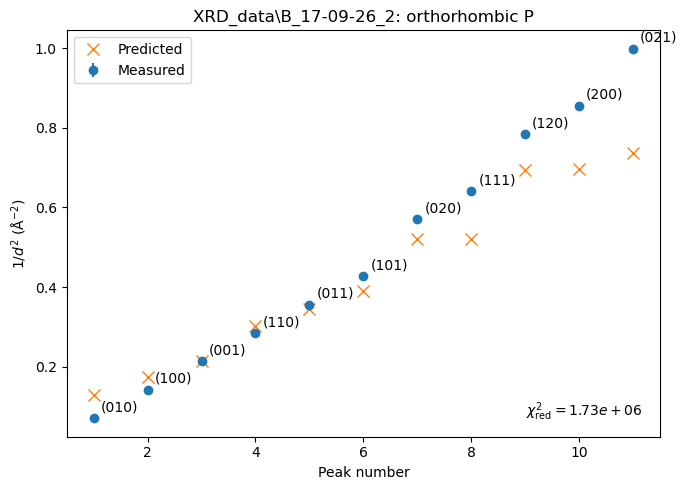

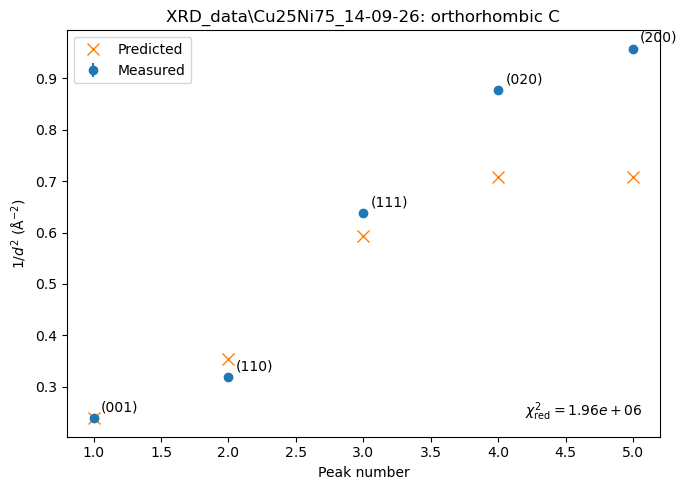

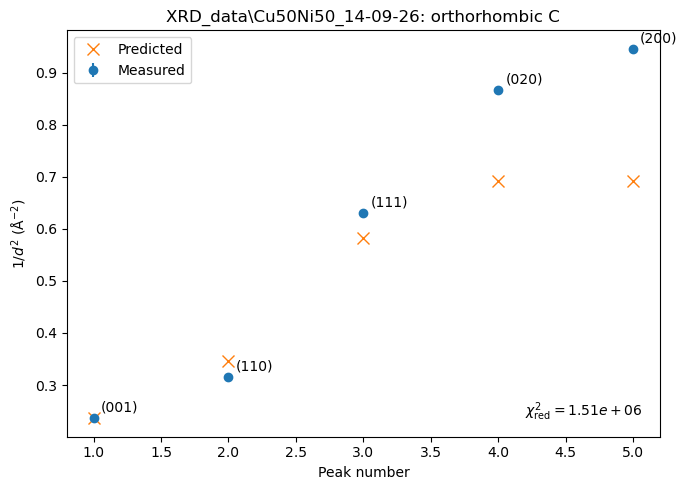

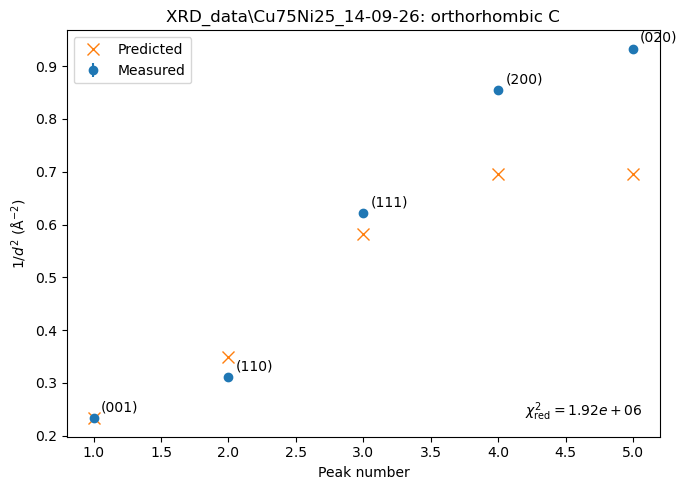

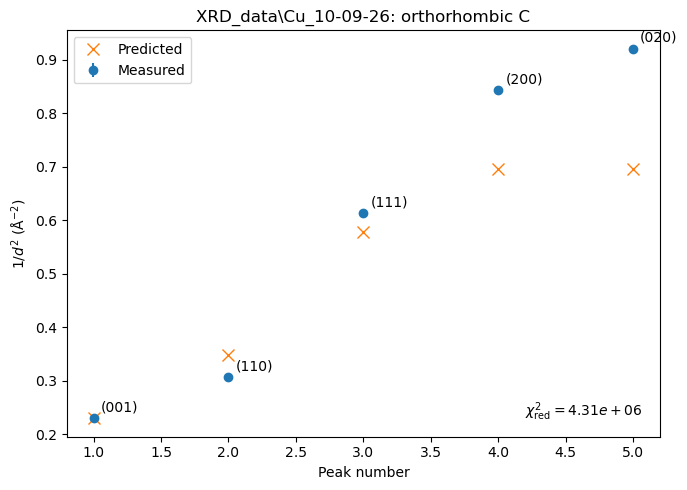

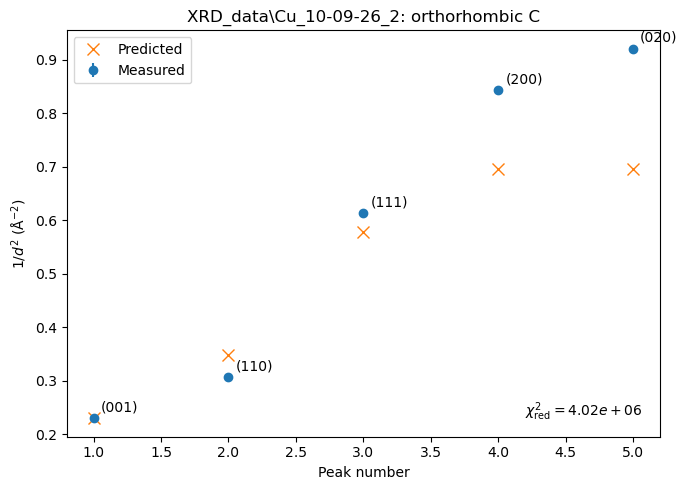

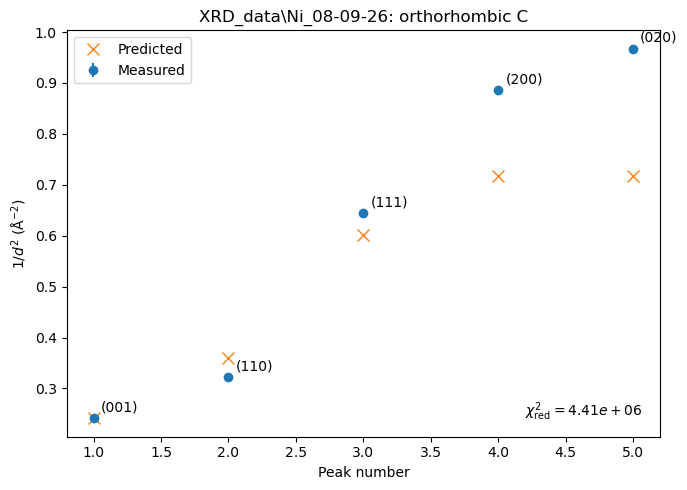

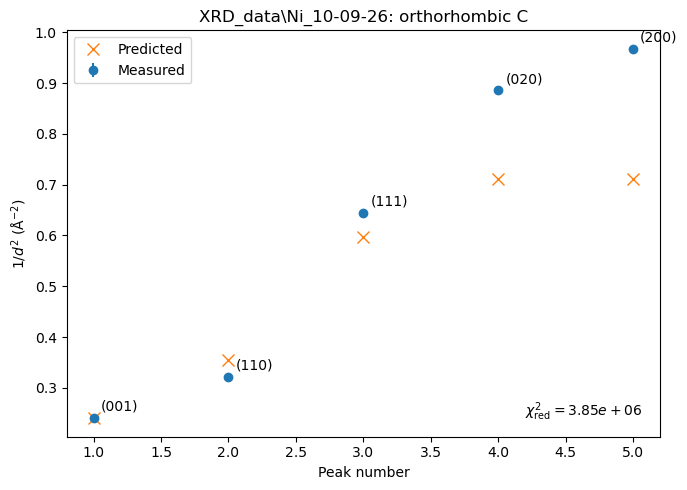

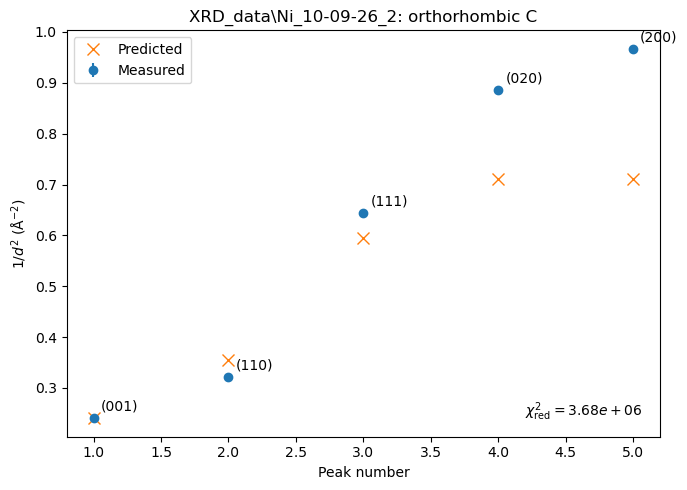

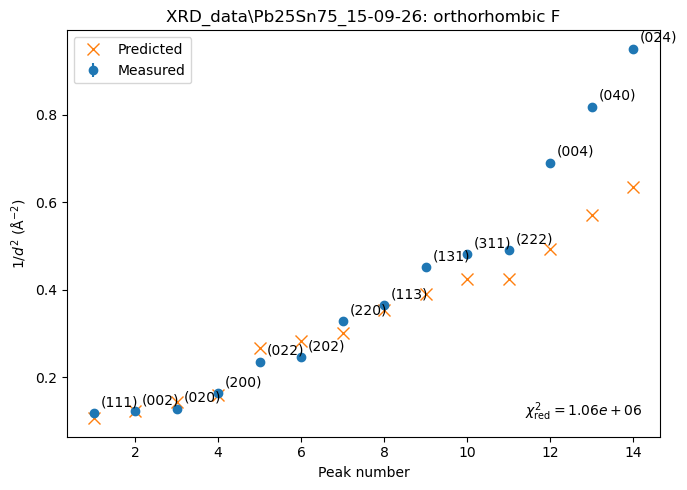

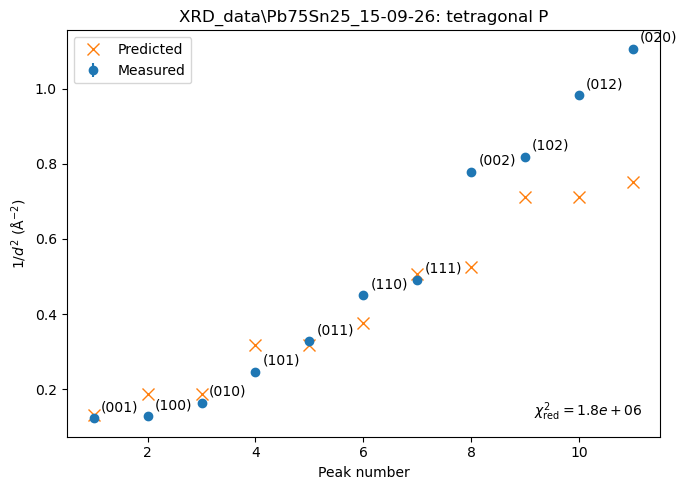

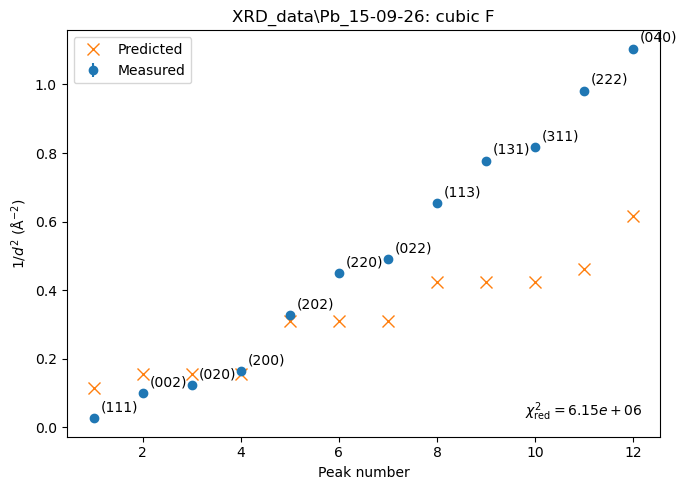

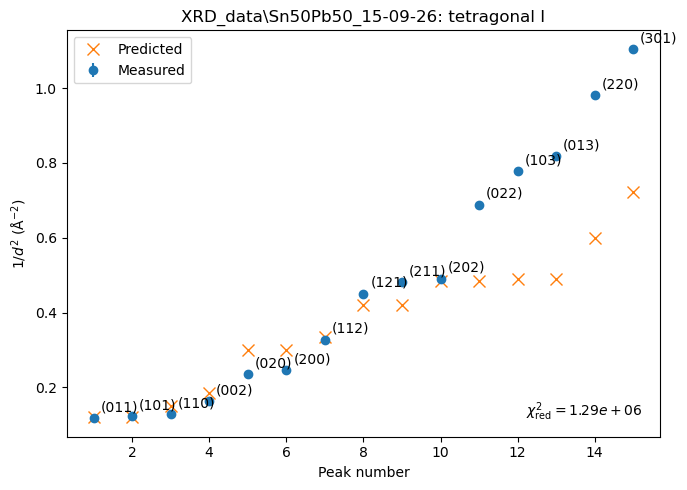

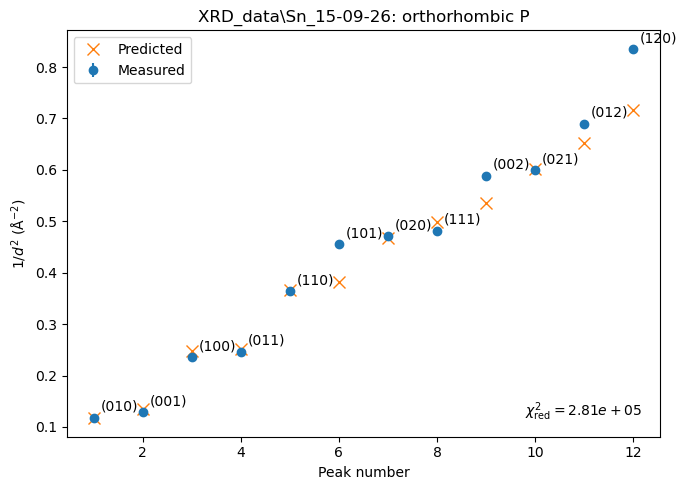

In [3]:
# ============================================================
# GENERALIZED CRYSTAL STRUCTURE TEST
#
# Uses peak_d and peak_d_errors from the first cell.
#
# IMPORTANT:
# We now require the measured peaks to correspond to the
# FIRST predicted allowed reflections. This prevents the
# optimizer from cherry-picking arbitrary high-index peaks.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares


# ------------------------------------------------------------
# Allowed Miller indices from lattice centering
# ------------------------------------------------------------

def allowed_hkl(max_index, centering):

    hkls = []

    for h in range(max_index + 1):
        for k in range(max_index + 1):
            for l in range(max_index + 1):

                if h == 0 and k == 0 and l == 0:
                    continue

                if centering == "P":
                    allowed = True

                elif centering == "I":
                    allowed = (h + k + l) % 2 == 0

                elif centering == "F":
                    allowed = (
                        h % 2 == k % 2 == l % 2
                    )

                elif centering == "C":
                    allowed = (h + k) % 2 == 0

                else:
                    allowed = False

                if allowed:
                    hkls.append((h, k, l))

    return np.array(hkls)


# ------------------------------------------------------------
# Reciprocal-space equation
# ------------------------------------------------------------

def calculate_q(hkls, structure, parameters):

    h = hkls[:, 0]
    k = hkls[:, 1]
    l = hkls[:, 2]

    if structure == "cubic":

        a = parameters[0]

        q = (
            h**2 + k**2 + l**2
        ) / a**2

    elif structure == "tetragonal":

        a, c = parameters

        q = (
            (h**2 + k**2) / a**2
            + l**2 / c**2
        )

    elif structure == "orthorhombic":

        a, b, c = parameters

        q = (
            h**2 / a**2
            + k**2 / b**2
            + l**2 / c**2
        )

    return q


# ------------------------------------------------------------
# Generate the FIRST predicted reflections
# ------------------------------------------------------------

def predicted_peaks(parameters,
                     structure,
                     centering,
                     n_peaks,
                     max_index=8):

    hkls = allowed_hkl(
        max_index,
        centering
    )

    q = calculate_q(
        hkls,
        structure,
        parameters
    )

    # Sort by increasing 1/d^2
    order = np.argsort(q)

    q = q[order]
    hkls = hkls[order]

    # Take the first n_peaks
    q = q[:n_peaks]
    hkls = hkls[:n_peaks]

    return q, hkls


# ------------------------------------------------------------
# Fit a structure
# ------------------------------------------------------------

def fit_structure(q_exp,
                  q_err,
                  structure,
                  centering,
                  max_index=8):

    n_peaks = len(q_exp)

    # --------------------------------------------------------
    # Initial guesses and bounds
    #
    # These are deliberately broad, but physically reasonable
    # for ordinary crystalline materials.
    # --------------------------------------------------------

    if structure == "cubic":

        initial = [4.0]
        lower = [2.0]
        upper = [8.0]

    elif structure == "tetragonal":

        initial = [4.0, 4.0]
        lower = [2.0, 2.0]
        upper = [8.0, 10.0]

    elif structure == "orthorhombic":

        initial = [4.0, 4.0, 4.0]
        lower = [2.0, 2.0, 2.0]
        upper = [10.0, 10.0, 12.0]

    # --------------------------------------------------------
    # Residual function
    # --------------------------------------------------------

    def residuals(parameters):

        q_pred, hkls = predicted_peaks(
            parameters,
            structure,
            centering,
            n_peaks,
            max_index
        )

        return (
            q_pred - q_exp
        ) / q_err

    # --------------------------------------------------------
    # Fit
    # --------------------------------------------------------

    result = least_squares(
        residuals,
        initial,
        bounds=(lower, upper),
        max_nfev=10000
    )

    parameters = result.x

    q_pred, hkls = predicted_peaks(
        parameters,
        structure,
        centering,
        n_peaks,
        max_index
    )

    residual = (
        q_pred - q_exp
    ) / q_err

    chi_squared = np.sum(residual**2)

    dof = n_peaks - len(parameters)

    if dof > 0:
        reduced_chi_squared = chi_squared / dof
    else:
        reduced_chi_squared = np.inf

    return {
        "structure": structure,
        "centering": centering,
        "parameters": parameters,
        "q_pred": q_pred,
        "hkls": hkls,
        "chi_squared": chi_squared,
        "reduced_chi_squared": reduced_chi_squared
    }


# ------------------------------------------------------------
# Structures to test
# ------------------------------------------------------------

structures_to_test = [

    ("cubic", "P"),
    ("cubic", "I"),
    ("cubic", "F"),

    ("tetragonal", "P"),
    ("tetragonal", "I"),

    ("orthorhombic", "P"),
    ("orthorhombic", "I"),
    ("orthorhombic", "F"),
    ("orthorhombic", "C")
]


# ------------------------------------------------------------
# Run everything
# ------------------------------------------------------------

all_results = {}

for name in peak_d:

    d = peak_d[name]
    d_err = peak_d_errors[name]

    # Experimental q = 1/d^2
    q_exp = 1 / d**2

    # Uncertainty propagation
    q_err = 2 * d_err / d**3

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    results = []

    for structure, centering in structures_to_test:

        result = fit_structure(
            q_exp,
            q_err,
            structure,
            centering
        )

        results.append(result)

        print(
            f"{structure:12s} {centering}: "
            f"χ²ᵣ = "
            f"{result['reduced_chi_squared']:.4g}"
        )

    all_results[name] = results


# ------------------------------------------------------------
# Print best fits
# ------------------------------------------------------------

for name, results in all_results.items():

    results_sorted = sorted(
        results,
        key=lambda x: x["reduced_chi_squared"]
    )

    best = results_sorted[0]

    print("\n" + "=" * 70)
    print(f"BEST FIT: {name}")
    print("=" * 70)

    print(
        f"Structure: "
        f"{best['structure']} {best['centering']}"
    )

    print(
        "Lattice parameters: "
        + ", ".join(
            f"{x:.4f} Å"
            for x in best["parameters"]
        )
    )

    print(
        f"Reduced χ² = "
        f"{best['reduced_chi_squared']:.4g}"
    )

    print("\nIndexing:")

    for i, (hkl, q_exp, q_pred) in enumerate(
        zip(
            best["hkls"],
            1 / peak_d[name]**2,
            best["q_pred"]
        ),
        start=1
    ):

        h, k, l = hkl

        print(
            f"{i:2d}: "
            f"({h}{k}{l})   "
            f"q_exp = {q_exp:.6f}   "
            f"q_pred = {q_pred:.6f}"
        )


# ------------------------------------------------------------
# Plot best fit for each sample
# ------------------------------------------------------------

for name, results in all_results.items():

    best = sorted(
        results,
        key=lambda x: x["reduced_chi_squared"]
    )[0]

    q_exp = 1 / peak_d[name]**2
    q_err = (
        2 * peak_d_errors[name]
        / peak_d[name]**3
    )

    x = np.arange(1, len(q_exp) + 1)

    fig, ax = plt.subplots(
        figsize=(7, 5)
    )

    ax.errorbar(
        x,
        q_exp,
        yerr=q_err,
        fmt="o",
        label="Measured"
    )

    ax.plot(
        x,
        best["q_pred"],
        "x",
        markersize=8,
        label="Predicted"
    )

    for i, hkl in enumerate(best["hkls"]):

        h, k, l = hkl

        ax.annotate(
            f"({h}{k}{l})",
            (x[i], q_exp[i]),
            xytext=(5, 5),
            textcoords="offset points"
        )

    ax.set_xlabel(
        "Peak number"
    )

    ax.set_ylabel(
        r"$1/d^2$ ($\mathrm{\AA}^{-2}$)"
    )

    ax.set_title(
        f"{name}: "
        f"{best['structure']} "
        f"{best['centering']}"
    )

    ax.legend()

    ax.text(
        0.97,
        0.05,
        f"$\\chi^2_\\mathrm{{red}} = "
        f"{best['reduced_chi_squared']:.3g}$",
        transform=ax.transAxes,
        ha="right"
    )

    plt.tight_layout()
    plt.show()